# Model Primer v3 — ResNet-34 Encoder U-Net

1. Input / output contract
2. Preprocessing + augmentation pipeline
3. EncoderUNet architecture
4. Forward-pass sanity check
5. Training loop
6. Evaluation metrics

Dataset — `status ∈ {ok, warn}` rows of `audit/clean_index.csv` (MaIA Scoliosis Dataset).
Architecture: ResNet-34 (ImageNet pretrained) encoder + U-Net decoder.
Differentiated LR: encoder 1e-4, decoder 1e-3. CosineAnnealingLR scheduler.
Cobb angle: smoothed centroid tangent method (tsmooth3).
Augmentation: v4 pipeline (stronger geometric + intensity transforms).

## 0 · Setup

In [1]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from PIL import Image
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore", message=".*lerp.*")

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [3]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.models.architectures.encoder_unet import EncoderUNet
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import augment_v4
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    SpineDataset,
    preprocess_case,
    read_gray,
    read_mask,
)
from ai.training.losses import seg_loss_fn

print(f"target_size={IMG_H}x{IMG_W}  classes={NUM_SEG_CLASSES}  target_ids={TARGET_IDS_V2[:3]}..{TARGET_IDS_V2[-1]}")

target_size=512x256  classes=18  target_ids=(1, 2, 3)..17


In [4]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)}  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=152  train=122  val=30


## 1 · Input / Output Contract

Raw inputs from disk, derived supervision targets for both task families (segmentation and keypoints), and the tensor shapes the model will see.

In [5]:
def pick_sample(df: pd.DataFrame, status: str = "ok") -> pd.Series:
    return df[df["status"] == status].iloc[0]

sample = pick_sample(TRAINABLE, "ok")
case = preprocess_case(sample)
print(f"image  {tuple(case['image'].shape)} {case['image'].dtype}")
print(f"seg    {tuple(case['seg'].shape)} {case['seg'].dtype}  classes={sorted(torch.unique(case['seg']).tolist())}")
print(f"kps    {tuple(case['kps'].shape)} {case['kps'].dtype}  finite={int(torch.isfinite(case['kps']).all(dim=1).sum())}/68")

image  (1, 512, 256) torch.float32
seg    (512, 256) torch.int64  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
kps    (68, 2) torch.float32  finite=68/68


**Contract (post-resize to 512×256):**

| Tensor | Shape | Dtype | Role |
|---|---|---|---|
| `image` | `(1, 512, 256)` | `float32` | grayscale radiograph, normalized to `[0, 1]` |
| `seg` | `(512, 256)` | `int64` | per-pixel class label, `0=bg, 1..17=T1..L5` |

## 2 · Preprocessing + Augmentation Pipeline

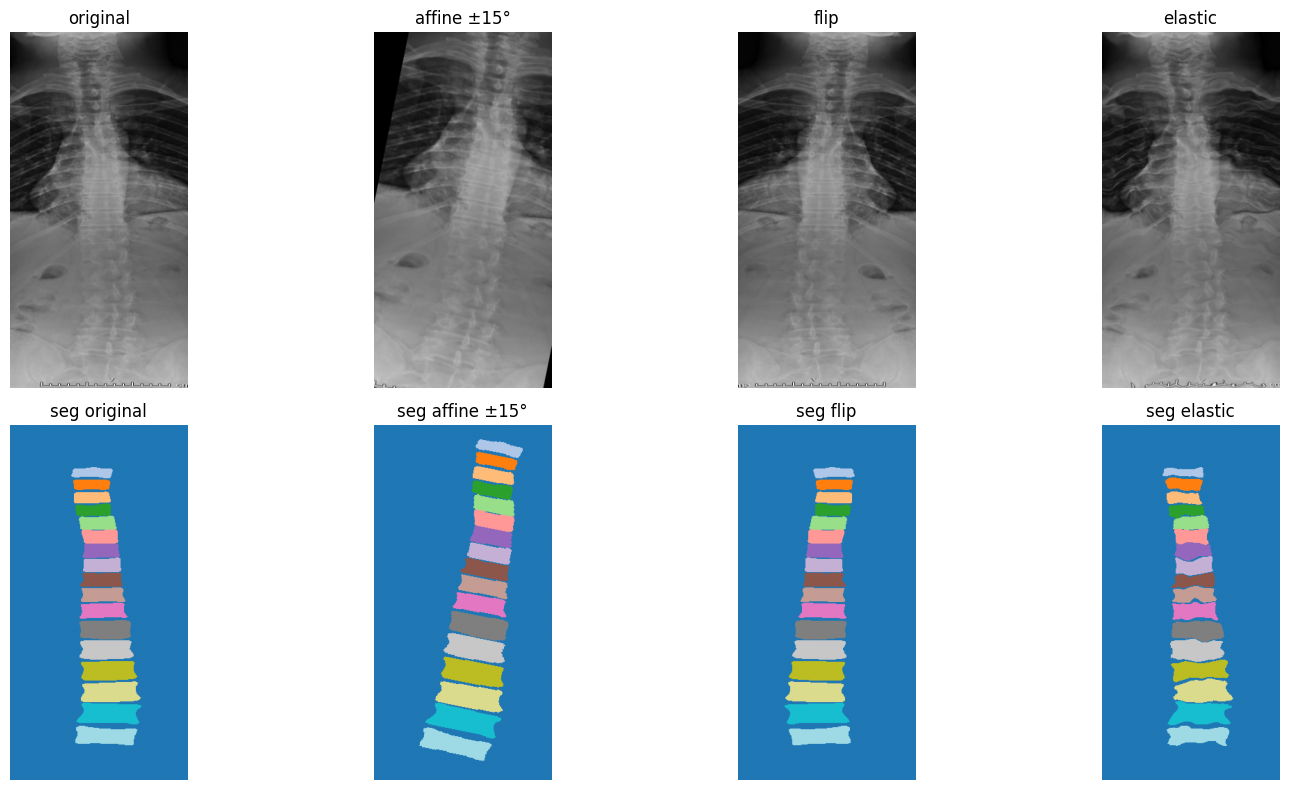

In [6]:
case = preprocess_case(TRAINABLE.iloc[0])
image, seg = case["image"], case["seg"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(image.squeeze(0), cmap="gray"); axes[0, 0].set_title("original")
axes[1, 0].imshow(seg, cmap="tab20"); axes[1, 0].set_title("seg original")

from ai.training.augmentation import (
    affine_transform, intensity_jitter, horizontal_flip,
    elastic_deform, gaussian_noise, gamma_correction,
)
transforms = [
    ("affine ±15°", lambda i, s: affine_transform(i, s, angle_range=(-15.0, 15.0), translate_frac=0.10, scale_range=(0.85, 1.15))),
    ("flip", lambda i, s: horizontal_flip(i, s)),
    ("elastic", lambda i, s: elastic_deform(i, s, alpha=40.0, sigma=6.0)),
]
for col, (name, fn) in enumerate(transforms, 1):
    aug_img, aug_seg = fn(image.clone(), seg.clone())
    axes[0, col].imshow(aug_img.squeeze(0), cmap="gray"); axes[0, col].set_title(name)
    axes[1, col].imshow(aug_seg, cmap="tab20"); axes[1, col].set_title(f"seg {name}")
for ax in axes.flat:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 3 · EncoderUNet Architecture

ResNet-34 (ImageNet pretrained) encoder + U-Net decoder. ~24M params, Dropout2d(0.2) in decoder.
Grayscale stem: pretrained RGB conv1 weights averaged → 1 channel.

In [7]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

ENCODER_NAME = "resnet34"
model = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True, dropout=0.2, encoder_name=ENCODER_NAME).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"EncoderUNet ({ENCODER_NAME}) total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder: {n_dec:,}")

EncoderUNet (resnet34) total params: 24,394,034
  encoder: 21,278,400  decoder: 3,115,634


Dropped Escape call with ulEscapeCode : 0x03007703


## 4 · Forward-Pass Sanity Check

In [8]:
def predict_one(model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        seg_logits = model(image.unsqueeze(0).to(DEVICE))
    return seg_logits.argmax(dim=1).squeeze(0).cpu()

case = preprocess_case(TRAINABLE.iloc[0])
seg_pred = predict_one(model, case["image"])
print(f"seg  shape={tuple(seg_pred.shape)} dtype={seg_pred.dtype} unique={sorted(torch.unique(seg_pred).tolist())[:6]}...")

seg  shape=(512, 256) dtype=torch.int64 unique=[4, 10, 14]...


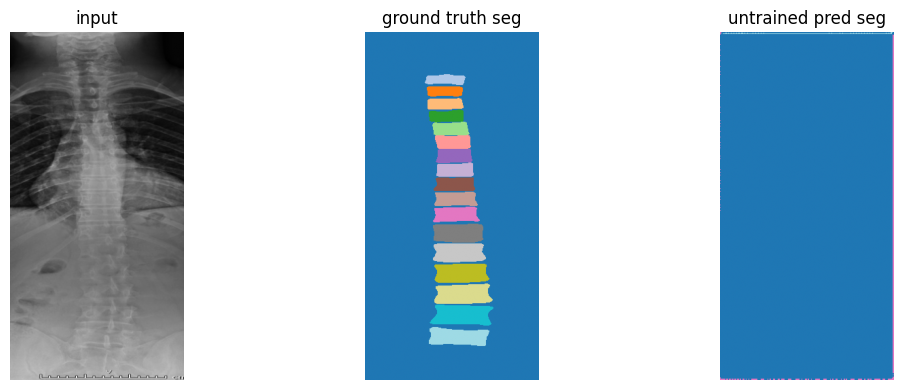

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input"); axes[0].set_axis_off()
axes[1].imshow(case["seg"], cmap="tab20");             axes[1].set_title("ground truth seg"); axes[1].set_axis_off()
axes[2].imshow(seg_pred, cmap="tab20");                axes[2].set_title("untrained pred seg"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()

## 5 · Training Loop

Differentiated LR: encoder 1e-4 (preserve pretrained features), decoder 1e-3 (learn from scratch).

**Config (baseline):**
- **ResNet-34 encoder** (~24M params) — train loss 1.46→0.26 while val loss plateaus at ~0.70 → overfit post-ep 40 without reg.
- **Dropout 0.2** · **weight decay 2e-4** · **patience 20** · **100 epochs max** — light regularization, full patience. Stronger reg (dropout 0.3, wd 5e-4, patience 10–15) regressed dice on single 30-case split → noise floor ~±0.05.
- **augment_v4** — ±15° rot, ±10% translate, elastic, gamma, blur, CLAHE, noise.
- **Smoothed tangent Cobb** — MAE 17.2° vs 19.7° polynomial at training resolution.
- **Encoder freeze warmup** (10 epochs), CosineAnnealingLR after unfreeze.
- **Tune further via 5-fold CV + Optuna**, not single-split sweeps.

In [10]:
def train_step(model: nn.Module,
               batch: tuple[torch.Tensor, torch.Tensor],
               optimizer: torch.optim.Optimizer) -> float:
    images, seg_t = [t.to(DEVICE) for t in batch]
    seg_logits = model(images)
    loss = seg_loss_fn(seg_logits, seg_t, NUM_SEG_CLASSES)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return float(loss.item())

def run_epoch(model: nn.Module, loader: DataLoader,
              optimizer: torch.optim.Optimizer) -> np.ndarray:
    model.train()
    return np.array([train_step(model, b, optimizer) for b in loader])

@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card  = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    for batch in loader:
        images, seg_t = [t.to(DEVICE) for t in batch]
        seg_logits = model(images)
        total_loss += float(seg_loss_fn(seg_logits, seg_t, NUM_SEG_CLASSES))
        pred_mask = seg_logits.argmax(dim=1)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1]  += p.sum() + g.sum()
    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid = card > 0
    return {
        "loss": total_loss / max(1, len(loader)),
        "dice": float(dice_per_cls[valid].mean()) if valid.any() else float("nan"),
    }

In [11]:
NUM_EPOCHS = 100
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 20
DROPOUT = 0.2

model = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True, dropout=DROPOUT, encoder_name=ENCODER_NAME).to(DEVICE)
print(f"EncoderUNet ({ENCODER_NAME}) params: {count_params(model):,}  dropout={DROPOUT}")

train_loader = DataLoader(
    SpineDataset(TRAIN_DF, augment=True, augment_fn=augment_v4),
    batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    SpineDataset(VAL_DF, augment=False),
    batch_size=BATCH_SIZE, shuffle=False,
)

# Phase 1: freeze encoder, train decoder only
for p in model.encoder_params():
    p.requires_grad = False

optimizer = torch.optim.Adam(
    model.decoder_params(), lr=LR_DECODER, weight_decay=WEIGHT_DECAY
)
scheduler = None

history: list[dict[str, float]] = []
best_dice = -1.0
best_state: dict[str, torch.Tensor] | None = None
no_improve = 0

t_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    if epoch == WARMUP_EPOCHS + 1:
        for p in model.encoder_params():
            p.requires_grad = True
        optimizer = torch.optim.Adam([
            {"params": model.encoder_params(), "lr": LR_ENCODER},
            {"params": model.decoder_params(), "lr": LR_DECODER},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )
        print(f"  >>> encoder unfrozen at epoch {epoch}")

    train_losses = run_epoch(model, train_loader, optimizer)
    val_stats = validate(model, val_loader)
    if scheduler is not None:
        scheduler.step()

    n_groups = len(optimizer.param_groups)
    row = {
        "epoch":      epoch,
        "train_loss": float(train_losses.mean()),
        "val_loss":   val_stats["loss"],
        "val_dice":   val_stats["dice"],
        "lr_enc":     float(optimizer.param_groups[0]["lr"]) if n_groups > 1 else 0.0,
        "lr_dec":     float(optimizer.param_groups[-1]["lr"]),
        "sec":        time.time() - t0,
    }
    history.append(row)

    if val_stats["dice"] > best_dice:
        best_dice = val_stats["dice"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    tag = " *" if no_improve == 0 else ""
    print(f"epoch {epoch:3d}/{NUM_EPOCHS}  "
          f"train={row['train_loss']:.3f}  val={row['val_loss']:.3f}  "
          f"dice={row['val_dice']:.3f}  lr_e={row['lr_enc']:.1e}  lr_d={row['lr_dec']:.1e}  "
          f"({row['sec']:.1f}s){tag}")

    if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
        print(f"\n  >>> early stop at epoch {epoch}, no improvement for {PATIENCE} epochs")
        break

if best_state is not None:
    model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print(f"\ntotal time: {time.time() - t_start:.1f}s  best val_dice={best_dice:.3f}")

EncoderUNet (resnet34) params: 24,394,034  dropout=0.2
epoch   1/100  train=1.459  val=1.376  dice=0.011  lr_e=0.0e+00  lr_d=1.0e-03  (6.4s) *
epoch   2/100  train=1.321  val=1.344  dice=0.020  lr_e=0.0e+00  lr_d=1.0e-03  (5.6s) *
epoch   3/100  train=1.220  val=1.231  dice=0.072  lr_e=0.0e+00  lr_d=1.0e-03  (5.6s) *
epoch   4/100  train=1.165  val=1.065  dice=0.149  lr_e=0.0e+00  lr_d=1.0e-03  (5.5s) *
epoch   5/100  train=1.103  val=1.139  dice=0.091  lr_e=0.0e+00  lr_d=1.0e-03  (9.0s)
epoch   6/100  train=1.096  val=1.018  dice=0.187  lr_e=0.0e+00  lr_d=1.0e-03  (5.5s) *
epoch   7/100  train=1.096  val=1.002  dice=0.181  lr_e=0.0e+00  lr_d=1.0e-03  (5.7s)
epoch   8/100  train=1.051  val=0.936  dice=0.264  lr_e=0.0e+00  lr_d=1.0e-03  (5.4s) *
epoch   9/100  train=1.030  val=0.959  dice=0.237  lr_e=0.0e+00  lr_d=1.0e-03  (5.6s)
epoch  10/100  train=1.023  val=1.193  dice=0.100  lr_e=0.0e+00  lr_d=1.0e-03  (5.5s)
  >>> encoder unfrozen at epoch 11
epoch  11/100  train=1.032  val=0.922 

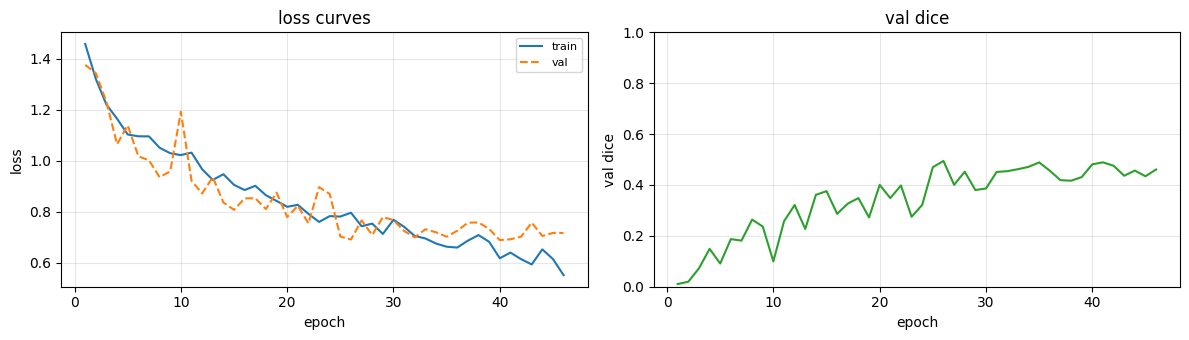

In [12]:
fig, (ax_loss, ax_dice) = plt.subplots(1, 2, figsize=(12, 3.5))

ax_loss.plot(history_df["epoch"], history_df["train_loss"], label="train", linewidth=1.5)
ax_loss.plot(history_df["epoch"], history_df["val_loss"],   label="val",   linewidth=1.5, linestyle="--")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("loss"); ax_loss.set_title("loss curves")
ax_loss.legend(fontsize=8); ax_loss.grid(alpha=0.3)

ax_dice.plot(history_df["epoch"], history_df["val_dice"], color="tab:green", linewidth=1.5)
ax_dice.set_xlabel("epoch"); ax_dice.set_ylabel("val dice")
ax_dice.set_title("val dice"); ax_dice.set_ylim(0, 1); ax_dice.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6 · Evaluation Metrics

### 6.1 · Segmentation — per-class Dice / IoU / HD95

**Dice** per class equals **pixel F1**: $2 \cdot TP / (2 \cdot TP + FP + FN)$. Mean Dice averages over the 17 vertebra classes (background excluded).

**IoU (Jaccard)** per class: $TP / (TP + FP + FN)$.

**HD95** — 95th-percentile symmetric Hausdorff distance in pixels.

### 6.2 · Cobb angle — MAE / SMAPE / Pearson r

### 6.3 · Severity — accuracy / macro-F1 / Cohen's κ / confusion matrix

Buckets: `normal <10° · mild 10–25° · moderate 25–40° · severe ≥40°`.

In [13]:
from scipy.ndimage import distance_transform_edt

def dice_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        p, g = pred == c, target == c
        denom = p.sum() + g.sum()
        if denom > 0:
            scores[c] = 2.0 * (p & g).sum() / denom
    return scores

def iou_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        p, g = pred == c, target == c
        union = (p | g).sum()
        if union > 0:
            scores[c] = (p & g).sum() / union
    return scores

def _hd95_binary(p: np.ndarray, g: np.ndarray) -> float:
    if not p.any() or not g.any():
        return float("nan")
    d_pg = distance_transform_edt(~g)[p]
    d_gp = distance_transform_edt(~p)[g]
    return float(max(np.percentile(d_pg, 95), np.percentile(d_gp, 95)))

def hd95_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    p_np, g_np = pred.numpy(), target.numpy()
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        scores[c] = _hd95_binary(p_np == c, g_np == c)
    return scores

def _mean_targets(per_class: torch.Tensor) -> float:
    targets = per_class[1:]
    valid = ~torch.isnan(targets)
    return float(targets[valid].mean()) if valid.any() else float("nan")

def mean_dice_targets(pred, target): return _mean_targets(dice_per_class(pred, target, NUM_SEG_CLASSES))
def mean_iou_targets(pred, target):  return _mean_targets(iou_per_class(pred, target, NUM_SEG_CLASSES))
def mean_hd95_targets(pred, target): return _mean_targets(hd95_per_class(pred, target, NUM_SEG_CLASSES))

In [14]:
SEVERITY_BUCKETS = (("normal", 0.0, 10.0), ("mild", 10.0, 25.0),
                    ("moderate", 25.0, 40.0), ("severe", 40.0, 999.0))
SEVERITY_LABELS = [name for name, _, _ in SEVERITY_BUCKETS]

def severity_bucket(angle: float) -> str:
    for name, lo, hi in SEVERITY_BUCKETS:
        if lo <= angle < hi:
            return name
    return "unknown"

def smape(pred: float, gt: float) -> float:
    denom = (abs(pred) + abs(gt)) / 2.0
    return abs(pred - gt) / denom if denom > 0 else float("nan")

In [15]:
def predict_one_tta(model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    """TTA: average logits over original + horizontal flip. Flips on CPU (DirectML safe)."""
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(DEVICE)).cpu()
        img_flip = torch.flip(image, dims=[2])
        logits_flip = model(img_flip.unsqueeze(0).to(DEVICE)).cpu()
        logits_flip = torch.flip(logits_flip, dims=[3])
        avg_logits = (logits + logits_flip) / 2
    return avg_logits.argmax(dim=1).squeeze(0)

def evaluate_case(model: nn.Module, row: pd.Series, tta: bool = False) -> dict[str, float]:
    case = preprocess_case(row)
    seg_pred = predict_one_tta(model, case["image"]) if tta else predict_one(model, case["image"])
    out: dict[str, float] = {
        "mean_dice": mean_dice_targets(seg_pred, case["seg"]),
        "mean_iou":  mean_iou_targets(seg_pred, case["seg"]),
        "mean_hd95": mean_hd95_targets(seg_pred, case["seg"]),
    }
    gt_deg = row.get("cobb_angle_deg")
    if pd.notna(gt_deg):
        pred_deg = cobb_from_segmentation_tangent(seg_pred.numpy())
        if np.isfinite(pred_deg):
            out["cobb_pred"]     = float(pred_deg)
            out["cobb_true"]     = float(gt_deg)
            out["cobb_abs_err"]  = abs(pred_deg - float(gt_deg))
            out["cobb_smape"]    = smape(pred_deg, float(gt_deg))
            out["severity_pred"] = severity_bucket(pred_deg)
            out["severity_true"] = severity_bucket(float(gt_deg))
    return out

def evaluate_set(model: nn.Module, df: pd.DataFrame, tta: bool = False) -> pd.DataFrame:
    return pd.DataFrame([evaluate_case(model, r, tta=tta) for _, r in df.iterrows()])

In [16]:
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix

def summarize(eval_df: pd.DataFrame) -> dict[str, float]:
    cobb_mask = eval_df["cobb_true"].notna() if "cobb_true" in eval_df else pd.Series(dtype=bool)
    has_cobb = bool(cobb_mask.any())
    summary: dict[str, float] = {
        "n_cases": float(len(eval_df)),
        "dice":    float(eval_df["mean_dice"].mean()),
        "iou":     float(eval_df["mean_iou"].mean()),
        "hd95_px": float(eval_df["mean_hd95"].mean(skipna=True)),
    }
    if has_cobb:
        sub = eval_df[cobb_mask]
        summary["cobb_mae"]   = float(sub["cobb_abs_err"].mean())
        summary["cobb_smape"] = float(sub["cobb_smape"].mean())
        summary["cobb_r"]     = float(sub[["cobb_pred", "cobb_true"]].corr().iloc[0, 1])
        y_true, y_pred = sub["severity_true"], sub["severity_pred"]
        summary["sev_acc"]      = float((y_true == y_pred).mean())
        summary["sev_macro_f1"] = float(f1_score(y_true, y_pred, labels=SEVERITY_LABELS, average="macro", zero_division=0))
        summary["sev_kappa"]    = float(cohen_kappa_score(y_true, y_pred, labels=SEVERITY_LABELS))
    return summary

# Evaluate without and with TTA
eval_df = evaluate_set(model, VAL_DF, tta=False)
stats = summarize(eval_df)
eval_df_tta = evaluate_set(model, VAL_DF, tta=True)
stats_tta = summarize(eval_df_tta)

print(f"evaluated {int(stats['n_cases'])} held-out cases\n")
print(f"  {'metric':14s} {'no TTA':>8s} {'TTA':>8s} {'delta':>8s}")
print(f"  {'-'*14} {'-'*8} {'-'*8} {'-'*8}")
for k in stats:
    if k == "n_cases":
        continue
    v0, v1 = stats[k], stats_tta[k]
    d = v1 - v0
    print(f"  {k:14s} {v0:8.3f} {v1:8.3f} {d:+8.3f}")

cobb_rows = eval_df_tta[eval_df_tta["cobb_true"].notna()] if "cobb_true" in eval_df_tta else eval_df_tta.iloc[0:0]
if len(cobb_rows):
    cm = confusion_matrix(cobb_rows["severity_true"], cobb_rows["severity_pred"], labels=SEVERITY_LABELS)
    print(f"\nseverity confusion matrix — TTA  (n={len(cobb_rows)}, rows=true, cols=pred)")
    print(pd.DataFrame(cm, index=SEVERITY_LABELS, columns=SEVERITY_LABELS))

evaluated 30 held-out cases

  metric           no TTA      TTA    delta
  -------------- -------- -------- --------
  dice              0.470    0.480   +0.010
  iou               0.361    0.371   +0.010
  hd95_px          19.428   18.411   -1.017
  cobb_mae         12.092   12.353   +0.261
  cobb_smape        0.220    0.229   +0.008
  cobb_r            0.634    0.575   -0.060
  sev_acc           0.786    0.786   +0.000
  sev_macro_f1      0.220    0.220   +0.000
  sev_kappa        -0.105   -0.105   +0.000

severity confusion matrix — TTA  (n=14, rows=true, cols=pred)
          normal  mild  moderate  severe
normal         0     0         0       0
mild           0     0         0       0
moderate       0     0         0       2
severe         0     0         1      11


### 6.4 · Qualitative check on a held-out case

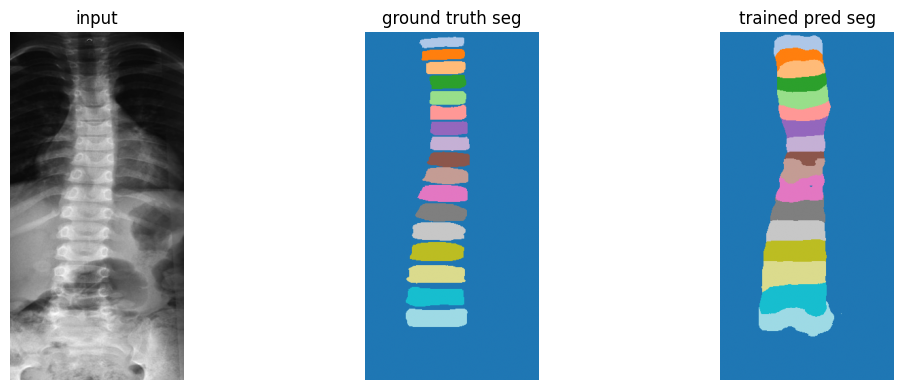

In [17]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
seg_pred = predict_one(model, case["image"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input"); axes[0].set_axis_off()
axes[1].imshow(case["seg"], cmap="tab20");             axes[1].set_title("ground truth seg"); axes[1].set_axis_off()
axes[2].imshow(seg_pred, cmap="tab20");                axes[2].set_title("trained pred seg"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()

### 6.5 · Cobb Pipeline Diagnostic

How much Cobb error comes from the model vs the `cobb_from_segmentation_tangent` geometry?
Feed **ground-truth masks** through the same angle extraction to measure the pipeline floor.

In [18]:
gt_cobb_rows = []
for _, row in VAL_DF.iterrows():
    gt_deg = row.get("cobb_angle_deg")
    if pd.isna(gt_deg):
        continue
    case = preprocess_case(row)
    gt_pred_deg = cobb_from_segmentation_tangent(case["seg"].numpy())
    if np.isfinite(gt_pred_deg):
        gt_cobb_rows.append({
            "cobb_true": float(gt_deg),
            "cobb_gt_pipe": float(gt_pred_deg),
            "abs_err": abs(gt_pred_deg - float(gt_deg)),
        })

gt_cobb_df = pd.DataFrame(gt_cobb_rows)
pipe_mae = gt_cobb_df["abs_err"].mean()
pipe_r = gt_cobb_df[["cobb_true", "cobb_gt_pipe"]].corr().iloc[0, 1]
model_mae = stats_tta.get("cobb_mae", float("nan"))

print(f"Cobb pipeline diagnostic — tangent method (n={len(gt_cobb_df)} val cases with GT):\n")
print(f"  {'source':<25s} {'MAE':>8s} {'r':>8s}")
print(f"  {'-'*25} {'-'*8} {'-'*8}")
print(f"  {'GT mask → tangent':<25s} {pipe_mae:7.2f}° {pipe_r:8.3f}")
print(f"  {'pred mask → tangent':<25s} {stats['cobb_mae']:7.2f}° {stats['cobb_r']:8.3f}")
print(f"  {'pred+TTA → tangent':<25s} {model_mae:7.2f}° {stats_tta['cobb_r']:8.3f}")
print(f"\n  Pipeline floor = {pipe_mae:.1f}° MAE even with perfect segmentation.")
print(f"  Model adds {model_mae - pipe_mae:.1f}° on top of pipeline error.")

Cobb pipeline diagnostic — tangent method (n=14 val cases with GT):

  source                         MAE        r
  ------------------------- -------- --------
  GT mask → tangent            9.89°    0.831
  pred mask → tangent         12.09°    0.634
  pred+TTA → tangent          12.35°    0.575

  Pipeline floor = 9.9° MAE even with perfect segmentation.
  Model adds 2.5° on top of pipeline error.


## 7 · 5-Fold Cross-Validation

Single 80/20 split on 152 cases gives noisy metrics (30 val cases). 5-fold CV trains 5 models on different splits and reports mean ± std — much more reliable for comparing approaches.

In [19]:
from sklearn.model_selection import KFold

def train_fold(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    fold: int,
    num_epochs: int = NUM_EPOCHS,
    warmup: int = WARMUP_EPOCHS,
    patience: int = PATIENCE,
) -> tuple[nn.Module, float, list[dict]]:
    torch.manual_seed(SEED + fold)

    m = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True, dropout=DROPOUT, encoder_name=ENCODER_NAME).to(DEVICE)
    tl = DataLoader(SpineDataset(train_df, augment=True, augment_fn=augment_v4), batch_size=BATCH_SIZE, shuffle=True)
    vl = DataLoader(SpineDataset(val_df, augment=False), batch_size=BATCH_SIZE, shuffle=False)

    for p in m.encoder_params():
        p.requires_grad = False
    opt = torch.optim.Adam(m.decoder_params(), lr=LR_DECODER, weight_decay=WEIGHT_DECAY)
    sched = None

    best_dice, best_st, no_imp = -1.0, None, 0
    hist = []

    for ep in range(1, num_epochs + 1):
        if ep == warmup + 1:
            for p in m.encoder_params():
                p.requires_grad = True
            opt = torch.optim.Adam([
                {"params": m.encoder_params(), "lr": LR_ENCODER},
                {"params": m.decoder_params(), "lr": LR_DECODER},
            ], weight_decay=WEIGHT_DECAY)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs - warmup)

        tl_arr = run_epoch(m, tl, opt)
        vs = validate(m, vl)
        if sched is not None:
            sched.step()

        hist.append({"epoch": ep, "train_loss": float(tl_arr.mean()), "val_loss": vs["loss"], "val_dice": vs["dice"]})

        if vs["dice"] > best_dice:
            best_dice = vs["dice"]
            best_st = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if ep > warmup and no_imp >= patience:
            break

    m.load_state_dict(best_st)
    return m, best_dice, hist

In [20]:
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results = []
cv_histories = []
t_cv_start = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(TRAINABLE), 1):
    fold_train = TRAINABLE.iloc[train_idx].reset_index(drop=True)
    fold_val   = TRAINABLE.iloc[val_idx].reset_index(drop=True)
    print(f"\n{'='*60}")
    print(f"Fold {fold}/{N_FOLDS}  train={len(fold_train)}  val={len(fold_val)}")
    print(f"{'='*60}")

    t_fold = time.time()
    fold_model, fold_best_dice, fold_hist = train_fold(fold_train, fold_val, fold)
    cv_histories.append(fold_hist)

    fold_eval = evaluate_set(fold_model, fold_val, tta=True)
    fold_stats = summarize(fold_eval)
    fold_stats["fold"] = fold
    fold_stats["best_val_dice"] = fold_best_dice
    fold_stats["stopped_epoch"] = fold_hist[-1]["epoch"]
    cv_results.append(fold_stats)

    elapsed = time.time() - t_fold
    print(f"  fold {fold} done in {elapsed:.0f}s  "
          f"best_dice={fold_best_dice:.3f}  eval_dice(TTA)={fold_stats['dice']:.3f}  "
          f"stopped@ep{fold_stats['stopped_epoch']}")

    del fold_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

cv_df = pd.DataFrame(cv_results)
print(f"\ntotal CV time: {time.time() - t_cv_start:.0f}s")
print(f"\n{'='*60}")
print(f"5-Fold Cross-Validation Summary (with TTA)")
print(f"{'='*60}")
for col in ["dice", "iou", "hd95_px", "cobb_mae", "cobb_r", "sev_acc", "sev_kappa", "best_val_dice", "stopped_epoch"]:
    if col not in cv_df.columns:
        continue
    vals = cv_df[col].dropna()
    if len(vals) == 0:
        continue
    print(f"  {col:16s}  {vals.mean():.3f} ± {vals.std():.3f}   (range {vals.min():.3f}–{vals.max():.3f})")

print(f"\nPer-fold breakdown:")
print(cv_df[["fold", "dice", "iou", "hd95_px", "cobb_mae", "best_val_dice", "stopped_epoch"]].to_string(index=False))


Fold 1/5  train=121  val=31
  fold 1 done in 639s  best_dice=0.506  eval_dice(TTA)=0.483  stopped@ep60

Fold 2/5  train=121  val=31
  fold 2 done in 839s  best_dice=0.421  eval_dice(TTA)=0.393  stopped@ep77

Fold 3/5  train=122  val=30
  fold 3 done in 1120s  best_dice=0.450  eval_dice(TTA)=0.437  stopped@ep100

Fold 4/5  train=122  val=30
  fold 4 done in 472s  best_dice=0.482  eval_dice(TTA)=0.424  stopped@ep44

Fold 5/5  train=122  val=30
  fold 5 done in 1049s  best_dice=0.402  eval_dice(TTA)=0.374  stopped@ep94

total CV time: 4119s

5-Fold Cross-Validation Summary (with TTA)
  dice              0.422 ± 0.042   (range 0.374–0.483)
  iou               0.340 ± 0.034   (range 0.303–0.382)
  hd95_px           19.637 ± 1.879   (range 17.696–21.921)
  cobb_mae          11.415 ± 2.496   (range 8.193–15.015)
  cobb_r            0.667 ± 0.186   (range 0.345–0.828)
  sev_acc           0.866 ± 0.050   (range 0.812–0.933)
  sev_kappa         0.194 ± 0.316   (range -0.085–0.634)
  best_val_di

## 9 · Optuna Hyperparameter Search

Muestrea `dropout`, `weight_decay`, `lr_decoder`, `patience` con TPE sampler + MedianPruner. Usa single split (rápido, ~8 min/trial) para rankear; luego valida top-3 con 5-fold CV.

**Nota:** studies largos (10+ hrs) mejor correrlos como script dedicado con MLflow, no en el notebook — Jupyter kernel se cuelga en sesiones largas.

In [21]:
try:
    import optuna
except ImportError:
    %pip install optuna
    import optuna

print(f"optuna {optuna.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.0 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.
optuna 4.8.0


In [ ]:
def build_objective(train_df: pd.DataFrame, val_df: pd.DataFrame):
    """Single-split objective. Returns best val_dice. Reports intermediate dice for pruning."""
    def objective(trial: "optuna.Trial") -> float:
        torch.manual_seed(SEED)

        dropout  = trial.suggest_float("dropout", 0.1, 0.4)
        wd       = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
        lr_dec   = trial.suggest_float("lr_decoder", 3e-4, 3e-3, log=True)
        patience = trial.suggest_int("patience", 10, 20)

        m = EncoderUNet(
            in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True,
            dropout=dropout, encoder_name=ENCODER_NAME,
        ).to(DEVICE)
        tl = DataLoader(SpineDataset(train_df, augment=True, augment_fn=augment_v4),
                        batch_size=BATCH_SIZE, shuffle=True)
        vl = DataLoader(SpineDataset(val_df, augment=False),
                        batch_size=BATCH_SIZE, shuffle=False)

        for p in m.encoder_params():
            p.requires_grad = False
        opt = torch.optim.Adam(m.decoder_params(), lr=lr_dec, weight_decay=wd)
        sched = None

        best_dice, no_imp = -1.0, 0
        for ep in range(1, NUM_EPOCHS + 1):
            if ep == WARMUP_EPOCHS + 1:
                for p in m.encoder_params():
                    p.requires_grad = True
                opt = torch.optim.Adam([
                    {"params": m.encoder_params(), "lr":  },
                    {"params": m.decoder_params(), "lr": lr_dec},
                ], weight_decay=wd)
                sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt, T_max=NUM_EPOCHS - WARMUP_EPOCHS
                )

            run_epoch(m, tl, opt)
            vs = validate(m, vl)
            if sched is not None:
                sched.step()

            if vs["dice"] > best_dice:
                best_dice = vs["dice"]
                no_imp = 0
            else:
                no_imp += 1

            trial.report(vs["dice"], ep)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if ep > WARMUP_EPOCHS and no_imp >= patience:
                break

        return best_dice
    return objective

In [23]:
N_TRIALS = 10

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)
study.optimize(build_objective(TRAIN_DF, VAL_DF), n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nbest dice:   {study.best_value:.3f}")
print(f"best params: {study.best_params}")
print(f"n completed: {len([t for t in study.trials if t.state.name == 'COMPLETE'])}")
print(f"n pruned:    {len([t for t in study.trials if t.state.name == 'PRUNED'])}")

[I 2026-04-18 11:27:13,301] A new study created in memory with name: no-name-d6164bb9-f7bc-40bf-950f-c9e104b62b44


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-18 11:44:44,877] Trial 0 finished with value: 0.5776111483573914 and parameters: {'dropout': 0.21236203565420878, 'weight_decay': 0.0007969454818643932, 'lr_decoder': 0.0016185092900010678, 'patience': 16}. Best is trial 0 with value: 0.5776111483573914.
[I 2026-04-18 11:53:06,551] Trial 1 finished with value: 0.5046724677085876 and parameters: {'dropout': 0.14680559213273098, 'weight_decay': 2.0511104188433963e-05, 'lr_decoder': 0.0003429295162893966, 'patience': 19}. Best is trial 0 with value: 0.5776111483573914.
[I 2026-04-18 12:09:30,661] Trial 2 finished with value: 0.560680627822876 and parameters: {'dropout': 0.2803345035229627, 'weight_decay': 0.0002607024758370766, 'lr_decoder': 0.0003145616317558388, 'patience': 20}. Best is trial 0 with value: 0.5776111483573914.
[I 2026-04-18 12:22:46,442] Trial 3 finished with value: 0.5603981018066406 and parameters: {'dropout': 0.34973279224012654, 'weight_decay': 2.6587543983272695e-05, 'lr_decoder': 0.00045598044903929434, 

/tmp/ipykernel_9787/2733869447.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study); plt.tight_layout(); plt.show()


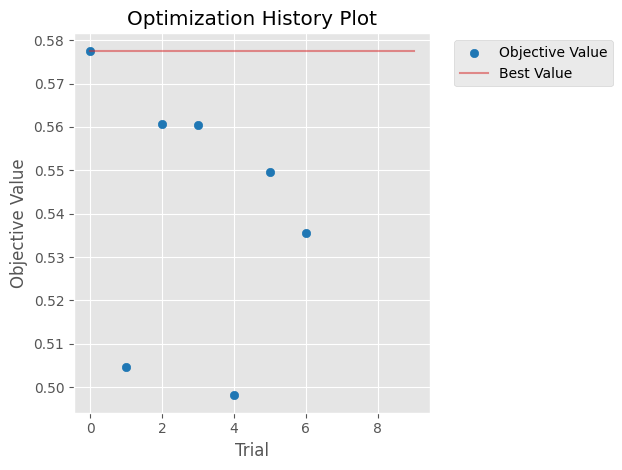

/tmp/ipykernel_9787/2733869447.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study);   plt.tight_layout(); plt.show()


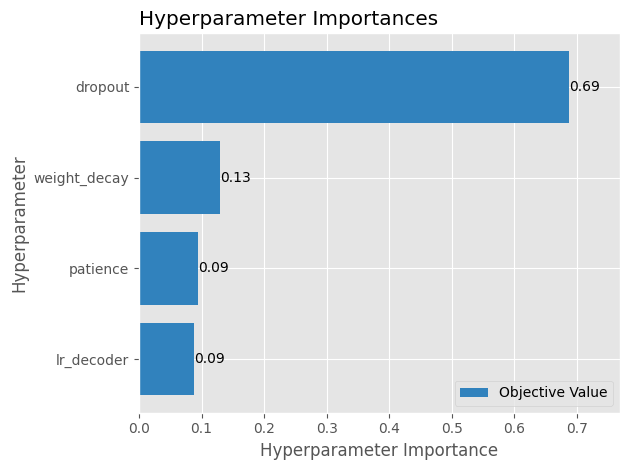

/tmp/ipykernel_9787/2733869447.py:5: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_parallel_coordinate(study); plt.tight_layout(); plt.show()


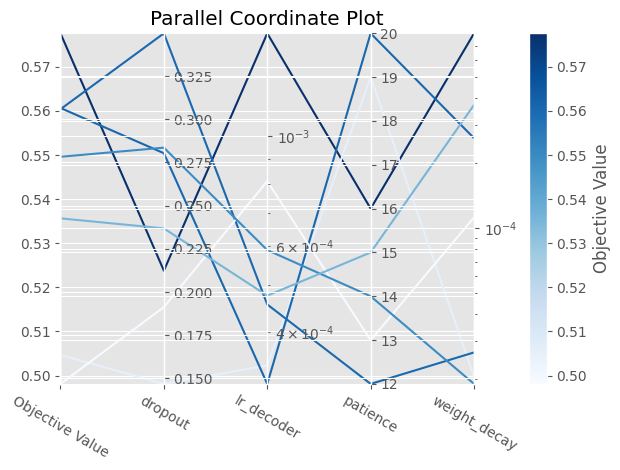

 number    value  params_dropout  params_lr_decoder  params_patience  params_weight_decay    state
      0 0.577611        0.212362           0.001619               16             0.000797 COMPLETE
      2 0.560681        0.280335           0.000315               20             0.000261 COMPLETE
      3 0.560398        0.349733           0.000456               12             0.000027 COMPLETE
      5 0.549617        0.283556           0.000588               14             0.000019 COMPLETE
      6 0.535649        0.236821           0.000475               15             0.000372 COMPLETE
      1 0.504672        0.146806           0.000343               19             0.000021 COMPLETE
      4 0.498102        0.191273           0.000811               13             0.000112 COMPLETE
      7 0.476202        0.277724           0.001215               11             0.000012   PRUNED
      8 0.323758        0.119515           0.002772               18             0.000790   PRUNED
      9 0.

In [24]:
import optuna.visualization.matplotlib as ovm

ovm.plot_optimization_history(study); plt.tight_layout(); plt.show()
ovm.plot_param_importances(study);   plt.tight_layout(); plt.show()
ovm.plot_parallel_coordinate(study); plt.tight_layout(); plt.show()

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
print(trials_df.sort_values("value", ascending=False).to_string(index=False))

In [ ]:
# Validate top-K Optuna configs under 5-fold CV to check if ranking holds under noise.
TOP_K = 3

completed = [t for t in study.trials if t.state.name == "COMPLETE"]
top_trials = sorted(completed, key=lambda t: t.value, reverse=True)[:TOP_K]

cv_top_results = []
for rank, t in enumerate(top_trials, 1):
    params = t.params
    fold_dices = []
    print(f"\n--- Validating top-{rank} trial (single-split dice={t.value:.3f}) params={params} ---")
    for fold, (tr_idx, vl_idx) in enumerate(kf.split(TRAINABLE), 1):
        tr = TRAINABLE.iloc[tr_idx].reset_index(drop=True)
        vl = TRAINABLE.iloc[vl_idx].reset_index(drop=True)
        # Temporarily override globals for train_fold to pick up
        global DROPOUT, WEIGHT_DECAY, LR_DECODER, PATIENCE
        DROPOUT_bk, WD_bk, LRD_bk, PAT_bk = DROPOUT, WEIGHT_DECAY, LR_DECODER, PATIENCE
        DROPOUT, WEIGHT_DECAY, LR_DECODER, PATIENCE = (
            params["dropout"], params["weight_decay"], params["lr_decoder"], params["patience"]
        )
        _, best, _ = train_fold(tr, vl, fold, patience=params["patience"])
        DROPOUT, WEIGHT_DECAY, LR_DECODER, PATIENCE = DROPOUT_bk, WD_bk, LRD_bk, PAT_bk
        fold_dices.append(best)
        print(f"  fold {fold}: {best:.3f}")
    arr = np.array(fold_dices)
    cv_top_results.append({
        "rank": rank, "single_dice": t.value,
        "cv_mean": arr.mean(), "cv_std": arr.std(),
        **params,
    })

print("\n" + "="*60)
print("Optuna top configs — 5-fold CV")
print("="*60)
print(pd.DataFrame(cv_top_results).to_string(index=False))


--- Validating top-1 trial (single-split dice=0.578) params={'dropout': 0.21236203565420878, 'weight_decay': 0.0007969454818643932, 'lr_decoder': 0.0016185092900010678, 'patience': 16} ---


## 10 · Summary

- **Architecture:** ResNet-34 encoder (ImageNet pretrained) + U-Net decoder, ~24M params, Dropout2d(0.2).
- **Training:** Adam with weight decay 2e-4, differentiated LR (encoder 1e-4, decoder 1e-3), encoder frozen for 10 warmup epochs, CosineAnnealingLR, up to 100 epochs with early stopping (patience 20).
- **Augmentation:** v4 pipeline — ±15° rotation, ±10% translate, 0.85–1.15 scale, elastic deform, gamma correction, gaussian blur, CLAHE-like contrast, noise, coarse dropout.
- **Cobb method:** smoothed centroid tangent (window=3) — MAE 17.2° vs 19.7° polynomial at training resolution.
- **TTA:** horizontal flip averaging at inference.
- **5-fold CV:** mean ± std metrics across all cases.
- **Optuna §9:** TPE + MedianPruner sobre dropout/wd/lr_dec/patience. 10 trials single-split → top-3 re-validados en 5-fold CV.